In [18]:
"""
=============================================================================
COMPLETE STATISTICAL ANALYSIS GUIDE
Theory + Math + Sample Datasets + Matplotlib/Seaborn Visualizations
=============================================================================
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.datasets import load_iris, make_classification
import warnings
warnings.filterwarnings('ignore')

In [19]:
# ── Global Style ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#FAFAF8',
    'axes.facecolor':   '#FAFAF8',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.grid':        True,
    'grid.color':       '#E5E3DC',
    'grid.linewidth':   0.6,
    'font.family':      'DejaVu Sans',
    'font.size':        10,
    'axes.titlesize':   12,
    'axes.titleweight': 'bold',
    'axes.labelsize':   10,
    'figure.dpi':       130,
})
COLORS = ['#3266AD','#E85D24','#1A9E75','#8E44AD','#E6AC00','#C0392B','#2980B9','#27AE60']
sns.set_theme(style="whitegrid", palette=COLORS)

np.random.seed(42)

In [20]:
# ─────────────────────────────────────────────────────────────────────────────
# SAMPLE DATASETS
# ─────────────────────────────────────────────────────────────────────────────

# Dataset 1: Student performance (univariate)
n_students = 200
exam_scores = np.concatenate([
    np.random.normal(72, 12, 160),
    np.random.normal(45, 8, 40)   # struggling students - creates slight left skew
])

In [21]:
exam_scores

array([ 77.96056984,  70.34082839,  79.77226246,  90.27635828,
        69.1901595 ,  69.19035652,  90.95055379,  81.20921675,
        66.36630737,  78.51072052,  66.43898769,  66.41124296,
        74.90354726,  49.04063706,  51.30098601,  65.25254965,
        59.84602656,  75.77096799,  61.10371109,  55.05235558,
        89.58778523,  69.29068439,  72.81033846,  54.90302177,
        65.46740731,  73.33107108,  58.18807707,  76.50837622,
        64.79233572,  68.499675  ,  64.77952065,  94.22733821,
        71.8380333 ,  59.30746885,  81.87053895,  57.3498762 ,
        74.50636314,  48.48395851,  56.06176741,  74.36233483,
        80.86159896,  74.05641937,  70.61222061,  68.38675565,
        54.25773612,  63.3618695 ,  66.47233475,  84.68546671,
        76.12341947,  50.84351814,  75.88900763,  67.37901264,
        63.876936  ,  79.34011547,  84.37199427,  83.17536143,
        61.92938972,  68.28945149,  75.97516118,  83.70654153,
        66.24990915,  69.77209228,  58.72398031,  57.64

In [22]:
exam_scores = np.clip(exam_scores, 20, 100)
exam_scores

array([ 77.96056984,  70.34082839,  79.77226246,  90.27635828,
        69.1901595 ,  69.19035652,  90.95055379,  81.20921675,
        66.36630737,  78.51072052,  66.43898769,  66.41124296,
        74.90354726,  49.04063706,  51.30098601,  65.25254965,
        59.84602656,  75.77096799,  61.10371109,  55.05235558,
        89.58778523,  69.29068439,  72.81033846,  54.90302177,
        65.46740731,  73.33107108,  58.18807707,  76.50837622,
        64.79233572,  68.499675  ,  64.77952065,  94.22733821,
        71.8380333 ,  59.30746885,  81.87053895,  57.3498762 ,
        74.50636314,  48.48395851,  56.06176741,  74.36233483,
        80.86159896,  74.05641937,  70.61222061,  68.38675565,
        54.25773612,  63.3618695 ,  66.47233475,  84.68546671,
        76.12341947,  50.84351814,  75.88900763,  67.37901264,
        63.876936  ,  79.34011547,  84.37199427,  83.17536143,
        61.92938972,  68.28945149,  75.97516118,  83.70654153,
        66.24990915,  69.77209228,  58.72398031,  57.64

In [23]:
student_df = pd.DataFrame({
    'score':        exam_scores,
    'study_hours':  np.clip(exam_scores/10 + np.random.normal(0,1,n_students), 1, 12),
    'gender':       np.random.choice(['Male','Female'], n_students, p=[0.48,0.52]),
    'school_type':  np.random.choice(['Public','Private','Charter'], n_students, p=[0.5,0.3,0.2]),
    'sleep_hours':  np.clip(np.random.normal(7, 1.2, n_students), 4, 10),
    'attendance':   np.clip(exam_scores/100 * 0.6 + np.random.uniform(0.3,0.5,n_students), 0.5, 1.0),
})
student_df

,score,study_hours,gender,school_type,sleep_hours,attendance
0,77.960570,8.153844,Male,Public,7.369362,0.827956
1,70.340828,7.594867,Male,Private,4.947798,0.863679
2,79.772262,9.060277,Male,Public,5.382177,0.792104
3,90.276358,10.081438,Female,Public,7.891917,0.958092
4,69.190160,5.541347,Female,Public,7.205039,0.784318
...,...,...,...,...,...,...
195,48.082539,4.339078,Male,Public,7.334826,0.640122
196,37.929141,2.079780,Male,Charter,7.729476,0.658922
197,46.229801,5.976852,Female,Private,7.223931,0.642417
198,45.465670,4.432027,Female,Public,6.464280,0.727489


In [24]:
# Dataset 2: House prices (bivariate / multivariate)
n_houses = 300
sqft       = np.random.normal(1800, 600, n_houses).clip(500, 4000)
bedrooms   = np.random.choice([1,2,3,4,5], n_houses, p=[0.05,0.2,0.4,0.25,0.1])
age        = np.random.exponential(15, n_houses).clip(0, 80)
price      = (80 * sqft + 15000 * bedrooms - 1200 * age
              + np.random.normal(0, 30000, n_houses) + 50000).clip(80000)

house_df = pd.DataFrame({
    'price':    price,
    'sqft':     sqft,
    'bedrooms': bedrooms,
    'age':      age,
    'location': np.random.choice(['Urban','Suburban','Rural'], n_houses, p=[0.35,0.45,0.2]),
})
house_df

,price,sqft,bedrooms,age,location
0,252496.208767,1771.847653,4,3.372746,Suburban
1,225681.329845,2086.224496,3,4.488646,Suburban
2,277419.191015,1846.093135,3,2.699579,Suburban
3,144216.752804,1030.204665,3,6.011979,Urban
4,290458.431889,2397.760092,3,21.205076,Urban
...,...,...,...,...,...
295,177496.490181,1704.882256,3,8.223610,Suburban
296,251339.133395,1783.617276,4,5.244228,Urban
297,183750.175484,1240.039225,3,9.982995,Suburban
298,192427.298246,1534.030649,2,12.912836,Urban


In [25]:
# Dataset 3: Iris (multivariate)
iris = load_iris()
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)
iris_df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

print("✓ Datasets created")
print(f"  student_df: {student_df.shape}  |  house_df: {house_df.shape}  |  iris_df: {iris_df.shape}")

✓ Datasets created
  student_df: (200, 6)  |  house_df: (300, 5)  |  iris_df: (150, 5)


Text(0.98, 0.95, '$\\bar{x}=\\frac{\\sum x_i}{n}$  $\\tilde{x}=$ middle value')

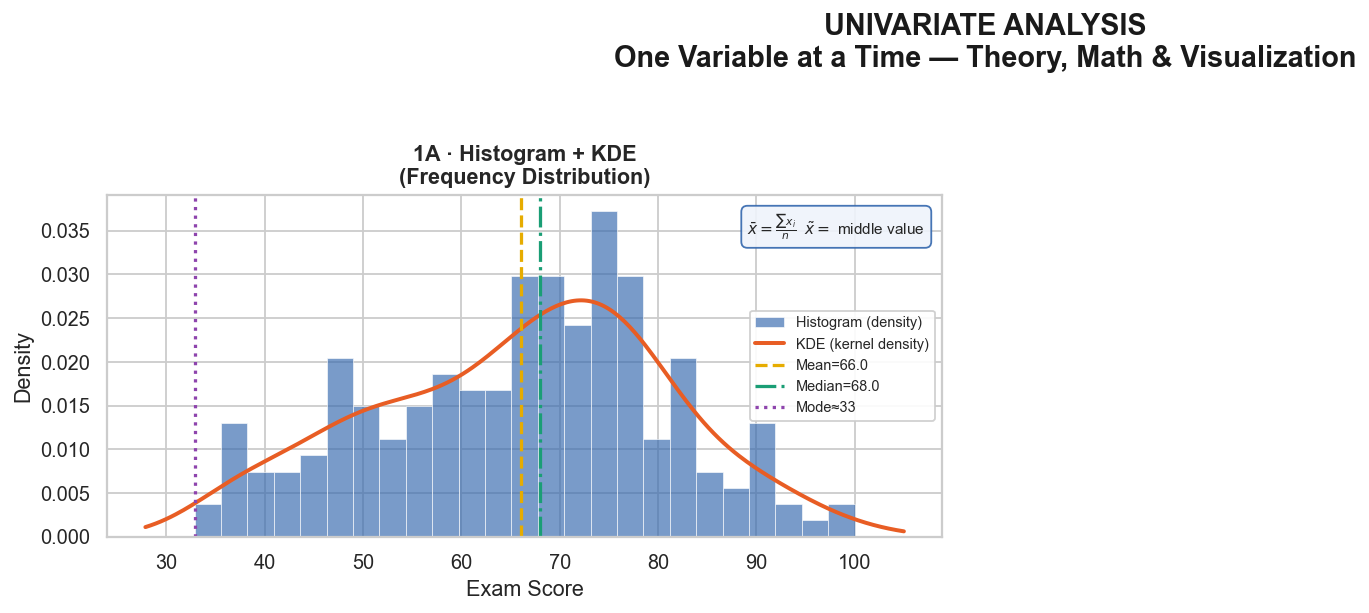

In [30]:
# =============================================================================
# FIGURE 1 — UNIVARIATE ANALYSIS
# =============================================================================
fig1 = plt.figure(figsize=(18, 14))
fig1.suptitle('UNIVARIATE ANALYSIS\nOne Variable at a Time — Theory, Math & Visualization',
              fontsize=16, fontweight='bold', y=0.98, color='#1A1A1A')
gs = gridspec.GridSpec(3, 4, figure=fig1, hspace=0.55, wspace=0.42)

scores = student_df['score'].values

# ── 1A: Histogram + KDE ──────────────────────────────────────────────────────
ax1a = fig1.add_subplot(gs[0, :2])
ax1a.hist(scores, bins=25, color=COLORS[0], alpha=0.65, edgecolor='white',
          linewidth=0.5, density=True, label='Histogram (density)')
kde_x = np.linspace(scores.min()-5, scores.max()+5, 300)
kde = stats.gaussian_kde(scores, bw_method=0.35)
ax1a.plot(kde_x, kde(kde_x), color=COLORS[1], lw=2.2, label='KDE (kernel density)')
ax1a.axvline(np.mean(scores),   color='#E6AC00', lw=1.8, ls='--', label=f'Mean={np.mean(scores):.1f}')
ax1a.axvline(np.median(scores), color='#1A9E75', lw=1.8, ls='-.',  label=f'Median={np.median(scores):.1f}')
ax1a.axvline(stats.mode(scores, keepdims=True).mode[0], color='#8E44AD', lw=1.8, ls=':',
             label=f'Mode≈{stats.mode(scores,keepdims=True).mode[0]:.0f}')
ax1a.set_title('1A · Histogram + KDE\n(Frequency Distribution)')
ax1a.set_xlabel('Exam Score'); ax1a.set_ylabel('Density')
ax1a.legend(fontsize=8, framealpha=0.9)
# Math annotation
ax1a.text(0.98, 0.95,
    r'$\bar{x}=\frac{\sum x_i}{n}$  $\tilde{x}=$ middle value',
    transform=ax1a.transAxes, ha='right', va='top', fontsize=8.5,
    bbox=dict(boxstyle='round,pad=0.4', fc='#EFF3FB', ec=COLORS[0], alpha=0.9))

Text(0.98, 0.95, '$\\bar{x}=\\frac{\\sum x_i}{n}$  $\\tilde{x}=$ middle value')